In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np


In [16]:
all_star_players = [
    # Eastern Conference Starters
    "Tyrese Haliburton",
    "Damian Lillard",
    "Giannis Antetokounmpo",
    "Jayson Tatum",
    "Joel Embiid",
    
    # Eastern Conference Reserves
    "Jalen Brunson",
    "Tyrese Maxey",
    "Donovan Mitchell",
    "Trae Young",
    "Paolo Banchero",
    "Scottie Barnes",
    "Jaylen Brown",
    "Julius Randle",
    "Bam Adebayo",
    
    # Western Conference Starters
    "Luka Doncic",
    "Shai Gilgeous-Alexander",
    "Kevin Durant",
    "LeBron James",
    "Nikola Jokic",
    
    # Western Conference Reserves
    "Devin Booker",
    "Stephen Curry",
    "Anthony Edwards",
    "Paul George",
    "Kawhi Leonard",
    "Karl-Anthony Towns",
    "Anthony Davis"
]
nba_data=pd.read_csv(r'C:\Users\mgang\Desktop\NBA_2023_24_shot_data.csv').dropna()
nba_data.shape




(232541, 29)

In [17]:
#data from nba_data only for 3 point shots
threes_data = nba_data[nba_data['SHOT_TYPE'] == '3PT Field Goal']
threes_data.head()
player_threes = threes_data.groupby('PLAYER_NAME').agg(
    FGM_3=('SHOT_MADE_FLAG', 'sum'),
    FGA_3=('SHOT_ATTEMPTED_FLAG', 'sum') 
)
player_threes['3PT%']=(player_threes['FGM_3']/player_threes['FGA_3'])*100
player_threes.head()


,FGM_3,FGA_3,3PT%
PLAYER_NAME,,,
AJ Green,71,180,39.444444
AJ Griffin,10,39,25.641026
AJ Lawson,15,56,26.785714
Aaron Gordon,51,165,30.909091
Aaron Holiday,84,217,38.709677


In [18]:
#player stats dataframe, grouped by player name and 
player_all_fg=nba_data.groupby('PLAYER_NAME').agg(
    FGM_all=('SHOT_MADE_FLAG', 'sum'),
    FGA_all=('SHOT_ATTEMPTED_FLAG', 'sum'),
)
player_all_fg['FG%']=(player_all_fg['FGM_all']/player_all_fg['FGA_all'])*100
player_all_fg.head()

,FGM_all,FGA_all,FG%
PLAYER_NAME,,,
AJ Green,89,212,41.981132
AJ Griffin,18,62,29.032258
AJ Lawson,58,130,44.615385
Aaron Gordon,467,834,55.995204
Aaron Holiday,186,417,44.604317


In [19]:
player_stats = pd.merge(player_threes, player_all_fg, on='PLAYER_NAME').reset_index()
player_stats['Effective_fg%']=(player_stats['FGM_all']+0.5*player_stats['FGM_3'])/player_stats['FGA_all']*100
# % above avg stat
player_stats['relative_FG%']= player_stats['FG%']-player_stats['FG%'].mean()
player_stats['relative_EFG%']= player_stats['Effective_fg%']-player_stats['Effective_fg%'].mean()
player_stats['relative_3PT%']= player_stats['3PT%']-player_stats['3PT%'].mean()
#all star or not
player_stats['all_star'] = player_stats['PLAYER_NAME'].apply(lambda x: 'yes' if x in all_star_players else 'no')

player_stats.head()

,PLAYER_NAME,FGM_3,FGA_3,3PT%,FGM_all,FGA_all,FG%,Effective_fg%,relative_FG%,relative_EFG%,relative_3PT%,all_star
0,AJ Green,71,180,39.444444,89,212,41.981132,58.726415,-2.836161,6.835909,7.770899,no
1,AJ Griffin,10,39,25.641026,18,62,29.032258,37.096774,-15.785035,-14.793732,-6.032520,no
2,AJ Lawson,15,56,26.785714,58,130,44.615385,50.384615,-0.201909,-1.505891,-4.887831,no
3,Aaron Gordon,51,165,30.909091,467,834,55.995204,59.052758,11.177911,7.162252,-0.764455,no
4,Aaron Holiday,84,217,38.709677,186,417,44.604317,54.676259,-0.212977,2.785753,7.036132,no


In [20]:

attempts_vs_percentage=px.scatter(player_stats, 
        x='FG%',
        y='FGA_all',
        color ='all_star',                        
        hover_data={'FG%': True, 'FGA_all': True, 'PLAYER_NAME': True}
                                 
        )
attempts_vs_percentage.update_layout(
    title="Player FG% vs FGA ",
    xaxis_title="Field Goal Percentage (FG%)",
    yaxis_title="Field Goals Attempted (FGA)"
)
attempts_vs_percentage.show()

c:\Users\mgang\anaconda3a\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [21]:
player_efg_chart=px.scatter(player_stats, 
                    x="Effective_fg%",
                    y= "FGA_all",
                    color='all_star',
                    hover_data={'PLAYER_NAME': True, 'FGA_all':True}
                    )
player_efg_chart.update_layout(
    title="Player Effective FG% vs FGA ",
    xaxis_title=" Effective Field Goal Percentage (EFG%)",
    yaxis_title="Field Goals Attempted (FGA)"
)
player_efg_chart.show()

c:\Users\mgang\anaconda3a\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [22]:
Team_fg=nba_data.groupby('TEAM_NAME').agg(
    team_fgm=('SHOT_MADE_FLAG', 'sum'), 
    team_fga=('SHOT_ATTEMPTED_FLAG', 'sum')
)
Team_fg['Team_FG%']=(Team_fg['team_fgm']/Team_fg['team_fga'])*100
Team_fg=Team_fg.reset_index()
Team_fg.head()

,TEAM_NAME,team_fgm,team_fga,Team_FG%
0,Atlanta Hawks,3529,7584,46.532173
1,Boston Celtics,4348,8989,48.370230
2,Brooklyn Nets,3334,7307,45.627480
3,Charlotte Hornets,3281,7133,45.997477
4,Chicago Bulls,3448,7339,46.981878


In [23]:
team_threes=nba_data[nba_data["SHOT_TYPE"]=="3PT Field Goal"]
Team_fg_threes=team_threes.groupby('TEAM_NAME').agg(
    team_3PM=('SHOT_MADE_FLAG', 'sum'), 
    team_3PA=('SHOT_ATTEMPTED_FLAG', 'sum')
)
Team_fg_threes['Team_3P%']=(Team_fg_threes['team_3PM']/Team_fg_threes['team_3PA'])*100
Team_fg_threes.head()

,team_3PM,team_3PA,Team_3P%
TEAM_NAME,,,
Atlanta Hawks,1125,3092,36.384217
Boston Celtics,1626,4246,38.294866
Brooklyn Nets,1089,3010,36.179402
Charlotte Hornets,989,2788,35.473458
Chicago Bulls,941,2630,35.779468


In [24]:
Team_stats=pd.merge(Team_fg, Team_fg_threes, on='TEAM_NAME' )
Team_stats['team_efg%']=(Team_stats['team_fgm']+0.5*Team_stats['team_3PM'])/Team_stats['team_fga']
Team_stats['League_avg_FG%']=Team_stats['Team_FG%'].mean()
Team_stats['net_FG%']=Team_stats['Team_FG%']-Team_stats['League_avg_FG%']
Team_stats

,TEAM_NAME,team_fgm,team_fga,Team_FG%,team_3PM,team_3PA,Team_3P%,team_efg%,League_avg_FG%,net_FG%
0,Atlanta Hawks,3529,7584,46.532173,1125,3092,36.384217,0.539491,47.302947,-0.770774
1,Boston Celtics,4348,8989,48.370230,1626,4246,38.294866,0.574146,47.302947,1.067283
2,Brooklyn Nets,3334,7307,45.627480,1089,3010,36.179402,0.530792,47.302947,-1.675467
3,Charlotte Hornets,3281,7133,45.997477,989,2788,35.473458,0.529300,47.302947,-1.305471
4,Chicago Bulls,3448,7339,46.981878,941,2630,35.779468,0.533928,47.302947,-0.321069
5,Cleveland Cavaliers,3874,8149,47.539575,1232,3410,36.129032,0.550988,47.302947,0.236628
6,Dallas Mavericks,4390,9179,47.826561,1459,3970,36.750630,0.557740,47.302947,0.523614
7,Denver Nuggets,4077,8301,49.114565,1084,2939,36.883294,0.556439,47.302947,1.811617
8,Detroit Pistons,3353,7236,46.337756,906,2602,34.819370,0.525981,47.302947,-0.965191
9,Golden State Warriors,3582,7515,47.664671,1211,3191,37.950486,0.557219,47.302947,0.361724


In [25]:
FG_hist = px.histogram(Team_stats, x="Team_FG%", nbins=5)
FG_hist.update_layout(title="Distribution of FG% for all teams")

FG_hist.show()

In [26]:
#visualization of histogram of team fg% in regular season and playoff on the same plot

In [27]:
playoff_shots = nba_data[nba_data["Season Type"] == "Playoffs"]

playoff_stats = playoff_shots.groupby('TEAM_NAME').agg(
    playoff_fgm=('SHOT_MADE_FLAG', 'sum'), 
    playoff_fga=('SHOT_ATTEMPTED_FLAG', 'sum')
).reset_index()


playoff_stats['playoff_fg%'] = (playoff_stats['playoff_fgm'] / playoff_stats['playoff_fga']) * 100


regular_shots=nba_data[nba_data["Season Type"]=="Regular Season"]
regular_stats=regular_shots.groupby('TEAM_NAME').agg(
    regular_fgm=('SHOT_MADE_FLAG', 'sum'), 
    regular_fga=('SHOT_ATTEMPTED_FLAG', 'sum')
)
regular_stats['regular_fg%']=(regular_stats['regular_fgm']/regular_stats['regular_fga'])*100

reg_and_playoff=pd.merge(regular_stats, playoff_stats, on='TEAM_NAME')
reg_and_playoff



,TEAM_NAME,regular_fgm,regular_fga,regular_fg%,playoff_fgm,playoff_fga,playoff_fg%
0,Boston Celtics,3601,7396,48.688480,747,1593,46.892655
1,Cleveland Cavaliers,3425,7148,47.915501,449,1001,44.855145
2,Dallas Mavericks,3535,7352,48.082155,855,1827,46.798030
3,Denver Nuggets,3610,7279,49.594725,467,1022,45.694716
4,Indiana Pacers,3855,7599,50.730359,761,1502,50.665779
5,LA Clippers,3473,7108,48.860439,214,493,43.407708
6,Los Angeles Lakers,3580,7177,49.881566,208,423,49.172577
7,Miami Heat,3266,7022,46.510966,178,406,43.842365
8,Milwaukee Bucks,3538,7258,48.746211,245,518,47.297297
9,Minnesota Timberwolves,3383,6974,48.508747,620,1326,46.757164


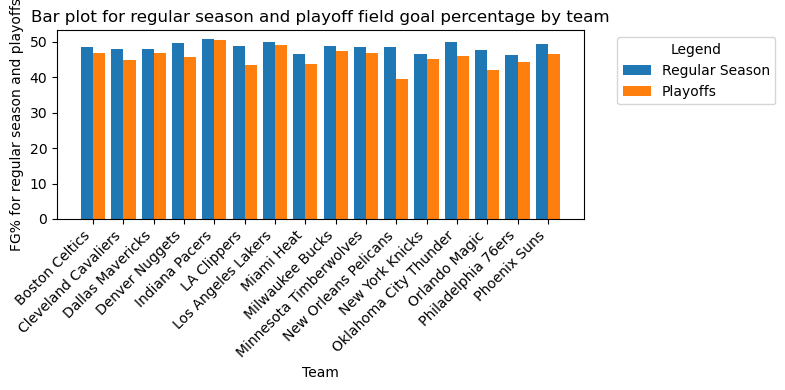

In [42]:
x = np.arange(len(reg_and_playoff['TEAM_NAME']))  # numeric positions
width = 0.4  # width of each bar

plt.figure(figsize=(8, 4))

plt.bar(x - width/2, reg_and_playoff['regular_fg%'], 
        width=width, label='Regular Season')

plt.bar(x + width/2, reg_and_playoff['playoff_fg%'], 
        width=width, label='Playoffs')

plt.xlabel('Team')
plt.ylabel('FG% for regular season and playoffs')
plt.title('Bar plot for regular season and playoff field goal percentage by team')

plt.xticks(x, reg_and_playoff['TEAM_NAME'], rotation=45, ha='right')
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

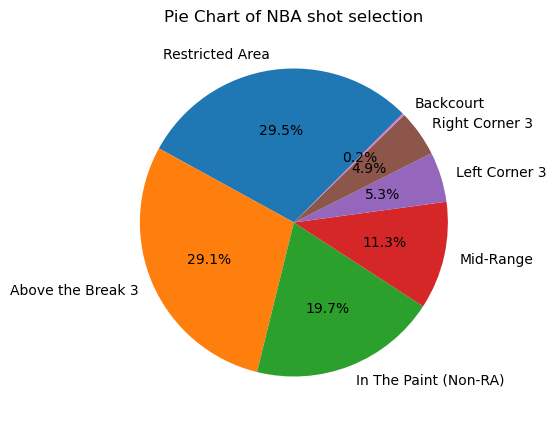

In [29]:
nba_shot_counts=nba_data['SHOT_ZONE_BASIC'].value_counts()
plt.figure(figsize=(5, 5))  
plt.pie(
   nba_shot_counts.values, 
    labels=nba_shot_counts.index, 
    autopct='%1.1f%%',  # Display percentages with 1 decimal place
    startangle=45,      
             
)
plt.title("Pie Chart of NBA shot selection")
plt.show()

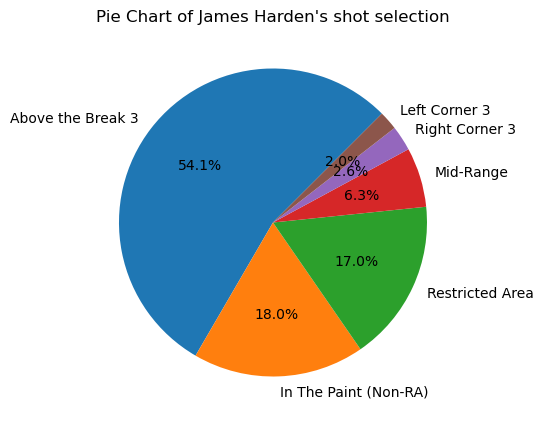

In [30]:
james_harden = nba_data[nba_data['PLAYER_NAME'] == 'James Harden'] 
harden_shot_counts=james_harden['SHOT_ZONE_BASIC'].value_counts()
plt.figure(figsize=(5, 5))  # Set figure size
plt.pie(
    harden_shot_counts.values, 
    labels=harden_shot_counts.index, 
    autopct='%1.1f%%',  
    startangle=45,      
             
)
plt.title("Pie Chart of James Harden's shot selection")
plt.show()


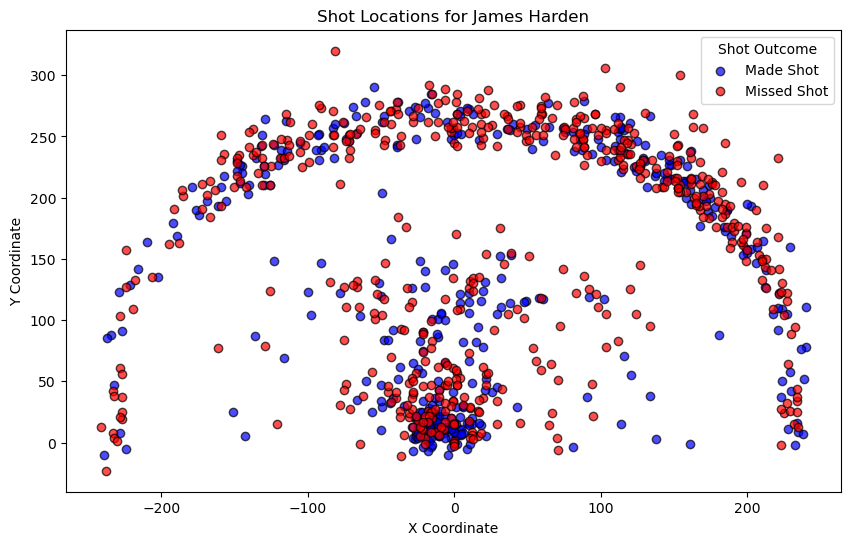

In [31]:
plt.figure(figsize=(10, 6))
made_shots = james_harden[james_harden['SHOT_MADE_FLAG'] == 1]
missed_shots = james_harden[james_harden['SHOT_MADE_FLAG'] == 0]

# Plot made shots
plt.scatter(made_shots['LOC_X'], made_shots['LOC_Y'], c='blue', label='Made Shot', edgecolor='k', alpha=0.7)
# Plot missed shots
plt.scatter(missed_shots['LOC_X'], missed_shots['LOC_Y'], c='red', label='Missed Shot', edgecolor='k', alpha=0.7)
plt.title('Shot Locations for James Harden')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')

# Add legend
plt.legend(title='Shot Outcome')

plt.show()

James Harden is a player known to take shots close to the basket, or outside the three-point line.  The scatterplot of shots below is from Demar Derozan, who is known to work mostly in the midrange.

In [32]:
derozan_shots = nba_data[nba_data['PLAYER_NAME'] == 'DeMar DeRozan'] 
derozan_shot_counts=derozan_shots['SHOT_ZONE_BASIC'].value_counts()

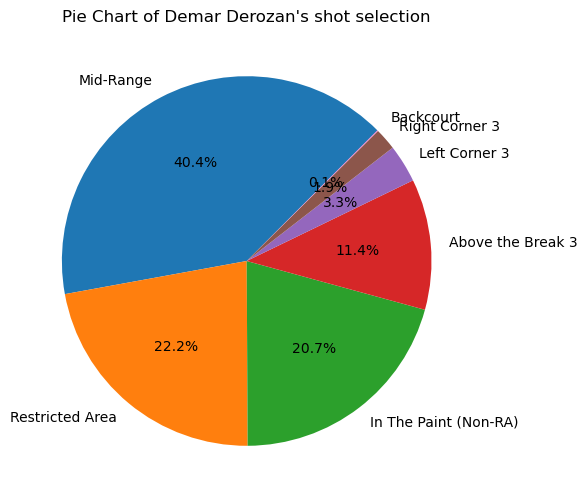

In [33]:
plt.figure(figsize=(6, 6))  
plt.pie(
    derozan_shot_counts.values, 
    labels=derozan_shot_counts.index, 
    autopct='%1.1f%%',  
    startangle=45,      
           
)
plt.title("Pie Chart of Demar Derozan's shot selection")
plt.show()

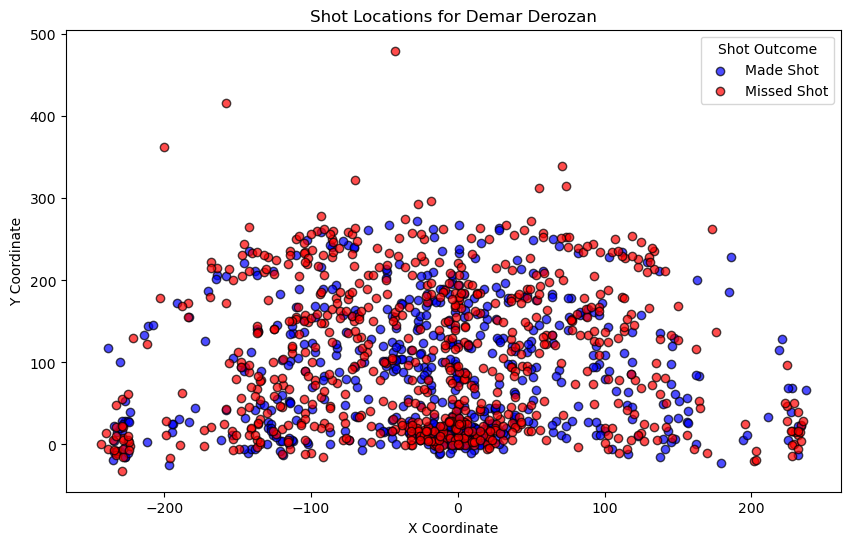

In [34]:
plt.figure(figsize=(10, 6))


made_shots_derozan = derozan_shots[derozan_shots['SHOT_MADE_FLAG'] == 1]
missed_shots_derozan = derozan_shots[derozan_shots['SHOT_MADE_FLAG'] == 0]

# Plot made shots
plt.scatter(made_shots_derozan['LOC_X'], made_shots_derozan['LOC_Y'], c='blue', label='Made Shot', edgecolor='k', alpha=0.7)
# Plot missed shots
plt.scatter(missed_shots_derozan['LOC_X'], missed_shots_derozan['LOC_Y'], c='red', label='Missed Shot', edgecolor='k', alpha=0.7)
plt.title('Shot Locations for Demar Derozan')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')

# Add legend
plt.legend(title='Shot Outcome')

plt.show()

In [35]:
data = pd.read_csv(r'C:\Users\mgang\Desktop\NBA_2023_24_shot_data.csv')

non_clutch_data = data[data['PERIOD'].isin([1, 2, 3])]
clutch_data = data[data['PERIOD'] == 4]

non_clutch_stats = non_clutch_data.groupby('PLAYER_NAME').agg(
    shots_attempted=('SHOT_ATTEMPTED_FLAG', 'sum'),
    shots_made=('SHOT_MADE_FLAG', 'sum')
)
non_clutch_stats['non_clutch_percentage'] = (
    non_clutch_stats['shots_made'] / non_clutch_stats['shots_attempted']
).fillna(0)

clutch_stats = clutch_data.groupby('PLAYER_NAME').agg(
    shots_attempted=('SHOT_ATTEMPTED_FLAG', 'sum'),
    shots_made=('SHOT_MADE_FLAG', 'sum')
)
clutch_stats['clutch_percentage'] = (
    clutch_stats['shots_made'] / clutch_stats['shots_attempted']
).fillna(0)

clutch_analysis = pd.merge(
    non_clutch_stats[['non_clutch_percentage']],
    clutch_stats[['clutch_percentage']],
    left_index=True,
    right_index=True,
    how='inner'
).reset_index()

fig = px.scatter(
    clutch_analysis,
    x='non_clutch_percentage',
    y='clutch_percentage',
    hover_name='PLAYER_NAME',
    labels={
        'non_clutch_percentage': 'Shooting % (Quarters 1-3)',
        'clutch_percentage': 'Shooting % (Quarter 4)'
    },
    title='Shooting Percentages: Quarters 1-3 vs Quarter 4',
    template='plotly_white'
)

fig.add_shape(
    type="line",
    x0=0, y0=0, x1=1, y1=1,
    line=dict(color="red", dash="dash"),
    xref='x', yref='y'
)

fig.show()



In [36]:
data['SHOT_ATTEMPTED_FLAG'] = data['SHOT_ATTEMPTED_FLAG'].astype(int)
data['SHOT_MADE_FLAG'] = data['SHOT_MADE_FLAG'].astype(int)

regular_season_data = data[data['Season Type'] == 'Regular Season']

team_efficiency = regular_season_data.groupby('TEAM_NAME').agg(
    total_shots=('SHOT_ATTEMPTED_FLAG', 'sum'),
    shots_made=('SHOT_MADE_FLAG', 'sum')
).reset_index()

team_efficiency['field_goal_percentage'] = (
    team_efficiency['shots_made'] / team_efficiency['total_shots']
) * 100

fig = px.scatter(
    team_efficiency,
    x='total_shots',
    y='field_goal_percentage',
    hover_name='TEAM_NAME',
    labels={
        'total_shots': 'Total Shots Taken',
        'field_goal_percentage': 'Field Goal Percentage (%)'
    },
    title='Team Shot Volume vs. Efficiency (Regular Season)',
    template='plotly_white'
)

fig.show()


In [37]:
data['SHOT_ATTEMPTED_FLAG'] = data['SHOT_ATTEMPTED_FLAG'].astype(int)
data['SHOT_MADE_FLAG'] = data['SHOT_MADE_FLAG'].astype(int)

regular_season_data = data[data['Season Type'] == 'Regular Season']
playoff_data = data[data['Season Type'] == 'Playoffs']

regular_season_action_type = regular_season_data.groupby('ACTION_TYPE').agg(
    total_shots=('SHOT_ATTEMPTED_FLAG', 'sum')
).reset_index()

playoff_action_type = playoff_data.groupby('ACTION_TYPE').agg(
    total_shots=('SHOT_ATTEMPTED_FLAG', 'sum')
).reset_index()

regular_season_action_type['percentage'] = (regular_season_action_type['total_shots'] /
                                            regular_season_action_type['total_shots'].sum()) * 100

playoff_action_type['percentage'] = (playoff_action_type['total_shots'] /
                                     playoff_action_type['total_shots'].sum()) * 100

def group_low_percentages(df): # had to look this up

    low_percentage_mask = df['percentage'] < 2
    
    other_percentage = df[low_percentage_mask]['percentage'].sum()
    
    df = df[~low_percentage_mask]
    
    other_df = pd.DataFrame({'ACTION_TYPE': ['Other'], 'percentage': [other_percentage]})
    
    df = pd.concat([df, other_df], ignore_index=True)
    
    return df

regular_season_action_type = group_low_percentages(regular_season_action_type)
playoff_action_type = group_low_percentages(playoff_action_type)

fig = px.pie(
    regular_season_action_type, 
    names='ACTION_TYPE', 
    values='percentage', 
    title='Action Type Distribution - Regular Season',
    color='ACTION_TYPE',
    color_discrete_map={'Field Goal': 'blue', 'Three Pointer': 'green', 'Free Throw': 'red', 'Other': 'grey'}
)

fig.show()

fig2 = px.pie(
    playoff_action_type, 
    names='ACTION_TYPE', 
    values='percentage', 
    title='Action Type Distribution - Playoffs',
    color='ACTION_TYPE',
    color_discrete_map={'Field Goal': 'blue', 'Three Pointer': 'green', 'Free Throw': 'red', 'Other': 'grey'}
)

fig2.show()


In [38]:
data['SHOT_ATTEMPTED_FLAG'] = data['SHOT_ATTEMPTED_FLAG'].astype(int)
data['SHOT_MADE_FLAG'] = data['SHOT_MADE_FLAG'].astype(int)

regular_season_data = data[data['Season Type'] == 'Regular Season']
playoff_data = data[data['Season Type'] == 'Playoffs']

regular_season_action_type = regular_season_data.groupby('SHOT_TYPE').agg(
    total_shots=('SHOT_ATTEMPTED_FLAG', 'sum')
).reset_index()

playoff_action_type = playoff_data.groupby('SHOT_TYPE').agg(
    total_shots=('SHOT_ATTEMPTED_FLAG', 'sum')
).reset_index()

regular_season_action_type['percentage'] = (regular_season_action_type['total_shots'] /
                                            regular_season_action_type['total_shots'].sum()) * 100

playoff_action_type['percentage'] = (playoff_action_type['total_shots'] /
                                     playoff_action_type['total_shots'].sum()) * 100

fig = px.pie(
    regular_season_action_type, 
    names='SHOT_TYPE', 
    values='percentage', 
    title='Shot Type Distribution - Regular Season',
    color='SHOT_TYPE',
    color_discrete_map={'Field Goal': 'blue', 'Three Pointer': 'green', 'Free Throw': 'red'}
)

fig.show()

fig2 = px.pie(
    playoff_action_type, 
    names='SHOT_TYPE', 
    values='percentage', 
    title='Shot Type Distribution - Playoffs',
    color='SHOT_TYPE',
    color_discrete_map={'Field Goal': 'blue', 'Three Pointer': 'green', 'Free Throw': 'red'}
)

fig2.show()


In [39]:
import plotly.graph_objects as go


In [40]:
data['SHOT_ATTEMPTED_FLAG'] = data['SHOT_ATTEMPTED_FLAG'].astype(int)
data['SHOT_MADE_FLAG'] = data['SHOT_MADE_FLAG'].astype(int)

playoff_data = data[data['Season Type'] == 'Playoffs']

shot_comparison = playoff_data.groupby(['TEAM_NAME', 'SHOT_TYPE']).agg(
    shots_taken=('SHOT_ATTEMPTED_FLAG', 'sum')
).reset_index()

total_shots_per_team = shot_comparison.groupby('TEAM_NAME')['shots_taken'].sum().reset_index()

shot_comparison = shot_comparison.merge(total_shots_per_team, on='TEAM_NAME', suffixes=('', '_total'))

shot_comparison['percentage'] = (shot_comparison['shots_taken'] / shot_comparison['shots_taken_total']) * 100

fig = go.Figure()

for shot_type in shot_comparison['SHOT_TYPE'].unique():
    shot_type_data = shot_comparison[shot_comparison['SHOT_TYPE'] == shot_type]
    
    fig.add_trace(go.Bar(
        x=shot_type_data['TEAM_NAME'],
        y=shot_type_data['percentage'],
        name=shot_type,
        hovertemplate=shot_type_data['TEAM_NAME'] + "<br>Percentage: %{y:.2f}%<br>Type: %{text}",
        text=shot_type_data['SHOT_TYPE'],
    ))

fig.update_layout(
    barmode='stack',
    height=800,
    width=1200,
    xaxis_title='Teams',
    yaxis_title='Percentage of Shots Taken',
    showlegend=True,
    template='plotly_white',
    title={'text': 'Percentage of 3-Point vs. 2-Point Shots per Team (Playoffs)', 'x': 0.5},
    xaxis=dict(
        showticklabels=True,
        tickangle=45,
        rangeslider=dict(visible=True),
        fixedrange=False
    ),
)

fig.show()



In [41]:

data['SHOT_ATTEMPTED_FLAG'] = data['SHOT_ATTEMPTED_FLAG'].astype(int)
data['SHOT_MADE_FLAG'] = data['SHOT_MADE_FLAG'].astype(int)

regular_season_data = data[data['Season Type'] == 'Regular Season']

shot_comparison = regular_season_data.groupby(['TEAM_NAME', 'SHOT_TYPE']).agg(
    shots_taken=('SHOT_ATTEMPTED_FLAG', 'sum')
).reset_index()

total_shots_per_team = shot_comparison.groupby('TEAM_NAME')['shots_taken'].sum().reset_index()

shot_comparison = shot_comparison.merge(total_shots_per_team, on='TEAM_NAME', suffixes=('', '_total'))

shot_comparison['percentage'] = (shot_comparison['shots_taken'] / shot_comparison['shots_taken_total']) * 100

fig = go.Figure()

for shot_type in shot_comparison['SHOT_TYPE'].unique():
    shot_type_data = shot_comparison[shot_comparison['SHOT_TYPE'] == shot_type]
    
    fig.add_trace(go.Bar(
        x=shot_type_data['TEAM_NAME'],
        y=shot_type_data['percentage'],
        name=shot_type,
        hovertemplate=shot_type_data['TEAM_NAME'] + "<br>Percentage: %{y:.2f}%<br>Type: %{text}",
        text=shot_type_data['SHOT_TYPE'],
    ))

fig.update_layout(
    barmode='stack',
    height=800,
    width=1200,
    xaxis_title='Teams',
    yaxis_title='Percentage of Shots Taken',
    showlegend=True,
    template='plotly_white',
    title={'text': 'Percentage of 3-Point vs. 2-Point Shots per Team (Regular Season)', 'x': 0.5},
    xaxis=dict(
        showticklabels=True,
        tickangle=45,
        rangeslider=dict(visible=True),
        fixedrange=False
    ),
)

fig.show()
